# Video-title vs description similarity alignment

This notebook starts from the description cosine-similarity matrices written by `research/1.Merge-Drive-Descriptions.ipynb`, loads the canonical 20D video-title embedding export, builds a channel-by-channel video-title similarity matrix, and compares each of the three description similarity matrices against the title-derived matrix.

For every description source (`Jules`, `codex`, and `copilot` by default), the notebook reports:

- **Spearman rank correlation** over aligned upper-triangle channel pairs.
- **Kendall rank correlation** over aligned upper-triangle channel pairs.
- **Pearson correlation** over aligned upper-triangle channel pairs.
- **Nearest-neighbor overlap / Top-k match**: mean fraction of shared top-k neighbors per channel, excluding self-neighbors.


## 1) Setup

Mount Google Drive when running in Colab, then define the inputs from the merge notebook and the canonical 20D video-title embedding export. The defaults match the Drive paths used by the surrounding Graphiko research notebooks.

In [1]:
from __future__ import annotations

import json
import re
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kendalltau, pearsonr, spearmanr
from sklearn.metrics.pairwise import cosine_similarity

try:
    from google.colab import drive

    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as exc:
    print(f'Google Drive was not mounted automatically: {exc}')
    IN_COLAB = False

sns.set_theme(style='whitegrid', context='notebook')

DRIVE_ROOT = Path('/content/drive/MyDrive')
GRAPHIKO_ROOT = DRIVE_ROOT / 'Graphiko'

DESCRIPTION_SIMILARITY_DIR = (
    GRAPHIKO_ROOT
    / 'research/merged_channel_descriptions/latest/description_cosine_similarity_matrices'
)
VIDEO_EMBEDDINGS_CSV = (
    GRAPHIKO_ROOT
    / 'exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv'
)
OUTPUT_DIR = GRAPHIKO_ROOT / 'research/title_description_similarity_alignment/latest'
TABLES_DIR = OUTPUT_DIR / 'tables'
PLOTS_DIR = OUTPUT_DIR / 'plots'

TOP_K_VALUES = [3, 5, 10]
CHANNEL_AGGREGATION = 'centroid_mean_20d'
RUN_STARTED_AT = datetime.now(timezone.utc).isoformat()

for path in [TABLES_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f'Description similarity input dir: {DESCRIPTION_SIMILARITY_DIR}')
print(f'20D video-title embedding CSV: {VIDEO_EMBEDDINGS_CSV}')
print(f'Output dir: {OUTPUT_DIR}')

Mounted at /content/drive
Description similarity input dir: /content/drive/MyDrive/Graphiko/research/merged_channel_descriptions/latest/description_cosine_similarity_matrices
20D video-title embedding CSV: /content/drive/MyDrive/Graphiko/exports/video_embeddings_reduced/latest/business_cluster_video_embeddings_reduced_20d.csv
Output dir: /content/drive/MyDrive/Graphiko/research/title_description_similarity_alignment/latest


## 2) Load description similarity matrices from the merge notebook

The merge notebook writes one CSV per description source with the schema `channel,<channel_1>,<channel_2>,...`. This section reads every `*_description_cosine_similarity.csv` file, validates that it is square, coerces values to numeric, and lightly symmetrizes each matrix to protect downstream statistics from CSV round-off.

In [2]:
def source_name_from_matrix_path(path: Path) -> str:
    name = path.stem
    suffix = '_description_cosine_similarity'
    return name.removesuffix(suffix) if name.endswith(suffix) else name


def load_similarity_matrix_csv(path: Path) -> pd.DataFrame:
    matrix = pd.read_csv(path, index_col=0)
    matrix.index = matrix.index.astype(str)
    matrix.columns = matrix.columns.astype(str)

    missing_columns = set(matrix.index) - set(matrix.columns)
    missing_rows = set(matrix.columns) - set(matrix.index)
    if missing_columns or missing_rows:
        raise ValueError(
            f'{path} is not square/aligned. Missing columns={sorted(missing_columns)[:5]}, '
            f'missing rows={sorted(missing_rows)[:5]}'
        )

    matrix = matrix.loc[matrix.index, matrix.index].apply(pd.to_numeric, errors='coerce')
    matrix = (matrix + matrix.T) / 2.0
    np.fill_diagonal(matrix.values, 1.0)
    return matrix


def load_description_similarity_matrices(input_dir: Path) -> dict[str, pd.DataFrame]:
    paths = sorted(input_dir.glob('*_description_cosine_similarity.csv'))
    if not paths:
        raise FileNotFoundError(
            f'No description similarity matrices found in {input_dir}. '
            'Run research/1.Merge-Drive-Descriptions.ipynb through its similarity-matrix section first.'
        )
    matrices = {source_name_from_matrix_path(path): load_similarity_matrix_csv(path) for path in paths}
    return matrices


description_matrices = load_description_similarity_matrices(DESCRIPTION_SIMILARITY_DIR)
print('Loaded description matrices:')
for source, matrix in description_matrices.items():
    print(f'  {source}: {matrix.shape[0]:,} × {matrix.shape[1]:,}')

Loaded description matrices:
  Jules: 26 × 26
  codex: 26 × 26
  copilot: 26 × 26


## 3) Load 20D video-title embeddings and compute a channel similarity matrix

Each row in the canonical reduced export is treated as one 20D video-title embedding. The channel representation is the mean centroid of its video-title embeddings, and the channel-by-channel title similarity matrix is cosine similarity between those centroids.

The notebook also writes the raw Euclidean centroid distance matrix for traceability, but the correlation and nearest-neighbor comparisons below use the title-derived cosine similarity matrix so higher values consistently mean “more similar,” matching the description matrices.

In [3]:
def embedding_columns(df: pd.DataFrame) -> list[str]:
    candidates = [
        [f'embedding_reduced_{i:02d}' for i in range(1, 21)],
        [f'embedding_{i:02d}' for i in range(1, 21)],
        [f'dim_{i}' for i in range(20)],
    ]
    for cols in candidates:
        if all(col in df.columns for col in cols):
            return cols

    reduced_cols = sorted([col for col in df.columns if col.startswith('embedding_reduced_')])
    if len(reduced_cols) == 20:
        return reduced_cols

    raise ValueError('Could not find exactly 20 embedding columns in the video-title embedding CSV.')


def load_video_title_embeddings(path: Path) -> tuple[pd.DataFrame, list[str]]:
    if not path.exists():
        raise FileNotFoundError(f'Missing 20D video-title embedding CSV: {path}')

    df = pd.read_csv(path)
    required = {'channel_name', 'video_title'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f'Missing required column(s) in {path}: {sorted(missing)}')

    cols = embedding_columns(df)
    df = df.dropna(subset=['channel_name']).copy()
    df['channel_name'] = df['channel_name'].astype(str)
    df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
    before = len(df)
    df = df.dropna(subset=cols)
    dropped = before - len(df)
    if dropped:
        print(f'Dropped {dropped:,} rows with incomplete 20D embeddings.')
    return df, cols


def compute_channel_title_similarity(
    videos: pd.DataFrame,
    embedding_cols: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    centroids = videos.groupby('channel_name', sort=True)[embedding_cols].mean()
    centroid_values = centroids.to_numpy(dtype=float)

    cosine = pd.DataFrame(
        cosine_similarity(centroid_values),
        index=centroids.index,
        columns=centroids.index,
    )
    cosine = (cosine + cosine.T) / 2.0
    np.fill_diagonal(cosine.values, 1.0)

    deltas = centroid_values[:, None, :] - centroid_values[None, :, :]
    distances = pd.DataFrame(
        np.linalg.norm(deltas, axis=2),
        index=centroids.index,
        columns=centroids.index,
    )
    np.fill_diagonal(distances.values, 0.0)
    return centroids, cosine, distances


videos_df, EMBEDDING_COLS = load_video_title_embeddings(VIDEO_EMBEDDINGS_CSV)
channel_centroids, title_similarity, title_distance = compute_channel_title_similarity(videos_df, EMBEDDING_COLS)

print(f'Loaded {len(videos_df):,} videos across {title_similarity.shape[0]:,} channels.')
print(f'Embedding columns: {EMBEDDING_COLS[0]} … {EMBEDDING_COLS[-1]}')
print(title_similarity.iloc[:5, :5])

Loaded 1,344 videos across 27 channels.
Embedding columns: embedding_reduced_01 … embedding_reduced_20
channel_name               20VC with Harry Stebbings  ARK Invest  \
channel_name                                                       
20VC with Harry Stebbings                   1.000000   -0.081228   
ARK Invest                                 -0.081228    1.000000   
Alex Hormozi                               -0.360769   -0.285696   
All-In Podcast                              0.375314   -0.068949   
Anthony Pompliano                          -0.234317    0.179451   

channel_name               Alex Hormozi  All-In Podcast  Anthony Pompliano  
channel_name                                                                
20VC with Harry Stebbings     -0.360769        0.375314          -0.234317  
ARK Invest                    -0.285696       -0.068949           0.179451  
Alex Hormozi                   1.000000       -0.659132          -0.101298  
All-In Podcast                -0.65

## 4) Persist the title-derived matrices

These CSVs make the title-derived reference matrix reusable without recomputing centroids. The similarity CSV is the primary reference for the comparison metrics; the distance CSV is included because it is often easier to inspect geometrically.

In [4]:
def write_matrix_csv(path: Path, matrix: pd.DataFrame) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    matrix.to_csv(path, index_label='channel', float_format='%.10f')


title_similarity_path = TABLES_DIR / 'video_title_centroid_cosine_similarity.csv'
title_distance_path = TABLES_DIR / 'video_title_centroid_euclidean_distance.csv'
channel_centroids_path = TABLES_DIR / 'video_title_channel_centroids_20d.csv'

write_matrix_csv(title_similarity_path, title_similarity)
write_matrix_csv(title_distance_path, title_distance)
channel_centroids.to_csv(channel_centroids_path, index_label='channel_name', float_format='%.10f')

print(f'Wrote title similarity matrix: {title_similarity_path}')
print(f'Wrote title distance matrix: {title_distance_path}')
print(f'Wrote channel centroids: {channel_centroids_path}')

Wrote title similarity matrix: /content/drive/MyDrive/Graphiko/research/title_description_similarity_alignment/latest/tables/video_title_centroid_cosine_similarity.csv
Wrote title distance matrix: /content/drive/MyDrive/Graphiko/research/title_description_similarity_alignment/latest/tables/video_title_centroid_euclidean_distance.csv
Wrote channel centroids: /content/drive/MyDrive/Graphiko/research/title_description_similarity_alignment/latest/tables/video_title_channel_centroids_20d.csv


## 5) Compare each description matrix to the video-title similarity matrix

For Pearson, Spearman, and Kendall correlations, each aligned square matrix is flattened to its upper triangle excluding the diagonal. This keeps every unordered channel pair exactly once and avoids inflating correlations with self-similarity values.

Nearest-neighbor overlap compares, for each channel, the top-k most similar neighbors in the description matrix with the top-k most similar neighbors in the video-title matrix. The reported score is the mean overlap fraction across aligned channels.

In [5]:
def align_matrices(left: pd.DataFrame, right: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    common = sorted(set(left.index) & set(right.index) & set(left.columns) & set(right.columns))
    if len(common) < 3:
        raise ValueError(f'Need at least 3 common channels for pairwise correlations; found {len(common)}.')
    return left.loc[common, common], right.loc[common, common]


def upper_triangle_values(matrix: pd.DataFrame) -> np.ndarray:
    values = matrix.to_numpy(dtype=float)
    mask = np.triu(np.ones(values.shape, dtype=bool), k=1)
    return values[mask]


def safe_correlation(fn, x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) < 2 or np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return np.nan, np.nan
    stat = fn(x, y)
    return float(stat.statistic), float(stat.pvalue)


def top_k_neighbors(matrix: pd.DataFrame, channel: str, k: int) -> list[str]:
    scores = matrix.loc[channel].drop(labels=[channel], errors='ignore')
    scores = scores.dropna().sort_values(ascending=False, kind='mergesort')
    return scores.head(k).index.tolist()


def nearest_neighbor_overlap(
    description_matrix: pd.DataFrame,
    title_matrix: pd.DataFrame,
    k: int,
) -> tuple[float, pd.DataFrame]:
    rows: list[dict[str, Any]] = []
    effective_k = min(k, max(len(description_matrix) - 1, 0))
    if effective_k <= 0:
        return np.nan, pd.DataFrame()

    for channel in description_matrix.index:
        desc_neighbors = top_k_neighbors(description_matrix, channel, effective_k)
        title_neighbors = top_k_neighbors(title_matrix, channel, effective_k)
        overlap = sorted(set(desc_neighbors) & set(title_neighbors))
        rows.append({
            'channel': channel,
            'k': effective_k,
            'description_neighbors': desc_neighbors,
            'title_neighbors': title_neighbors,
            'overlap_neighbors': overlap,
            'overlap_count': len(overlap),
            'overlap_fraction': len(overlap) / effective_k,
        })

    per_channel = pd.DataFrame(rows)
    return float(per_channel['overlap_fraction'].mean()), per_channel


def compare_description_to_title(
    source: str,
    description_matrix: pd.DataFrame,
    title_matrix: pd.DataFrame,
    top_k_values: list[int],
) -> tuple[dict[str, Any], pd.DataFrame]:
    desc_aligned, title_aligned = align_matrices(description_matrix, title_matrix)
    desc_values = upper_triangle_values(desc_aligned)
    title_values = upper_triangle_values(title_aligned)

    pearson_r, pearson_p = safe_correlation(pearsonr, desc_values, title_values)
    spearman_r, spearman_p = safe_correlation(spearmanr, desc_values, title_values)
    kendall_r, kendall_p = safe_correlation(kendalltau, desc_values, title_values)

    result: dict[str, Any] = {
        'source': source,
        'n_channels': int(desc_aligned.shape[0]),
        'n_channel_pairs': int(len(desc_values)),
        'pearson_correlation': pearson_r,
        'pearson_p_value': pearson_p,
        'spearman_rank_correlation': spearman_r,
        'spearman_p_value': spearman_p,
        'kendall_rank_correlation': kendall_r,
        'kendall_p_value': kendall_p,
    }

    per_channel_frames = []
    for k in top_k_values:
        mean_overlap, per_channel = nearest_neighbor_overlap(desc_aligned, title_aligned, k)
        result[f'top_{k}_mean_neighbor_overlap'] = mean_overlap
        if not per_channel.empty:
            per_channel = per_channel.copy()
            per_channel.insert(0, 'source', source)
            per_channel_frames.append(per_channel)

    per_channel_all = pd.concat(per_channel_frames, ignore_index=True) if per_channel_frames else pd.DataFrame()
    return result, per_channel_all


summary_rows = []
per_channel_rows = []
for source, description_matrix in description_matrices.items():
    summary, per_channel = compare_description_to_title(
        source,
        description_matrix,
        title_similarity,
        TOP_K_VALUES,
    )
    summary_rows.append(summary)
    per_channel_rows.append(per_channel)

comparison_summary = pd.DataFrame(summary_rows).sort_values('source').reset_index(drop=True)
per_channel_overlap = pd.concat(per_channel_rows, ignore_index=True) if per_channel_rows else pd.DataFrame()

comparison_summary

,source,n_channels,n_channel_pairs,pearson_correlation,pearson_p_value,spearman_rank_correlation,spearman_p_value,kendall_rank_correlation,kendall_p_value,top_3_mean_neighbor_overlap,top_5_mean_neighbor_overlap,top_10_mean_neighbor_overlap
0,Jules,26,325,0.350122,8.341996e-11,0.332480,7.920982e-10,0.222982,2.003910e-09,0.333333,0.438462,0.584615
1,codex,26,325,0.339587,3.253697e-10,0.315575,6.009402e-09,0.213257,9.697888e-09,0.320513,0.438462,0.623077
2,copilot,26,325,0.325203,1.924243e-09,0.323695,2.306287e-09,0.219107,3.786169e-09,0.320513,0.484615,0.596154


## 6) Write comparison outputs

The summary table contains one row per description source. The per-channel table stores the neighbor lists and overlaps that contribute to every Top-k score.

In [6]:
summary_path = TABLES_DIR / 'description_vs_video_title_similarity_correlations.csv'
per_channel_path = TABLES_DIR / 'description_vs_video_title_topk_neighbor_overlap_by_channel.csv'
metadata_path = OUTPUT_DIR / 'run_metadata.json'

comparison_summary.to_csv(summary_path, index=False, float_format='%.10f')
per_channel_overlap.to_csv(per_channel_path, index=False)

metadata = {
    'schema_name': 'graphiko.research.title_description_similarity_alignment',
    'schema_version': '1.0.0',
    'run_started_at': RUN_STARTED_AT,
    'description_similarity_dir': str(DESCRIPTION_SIMILARITY_DIR),
    'video_embeddings_csv': str(VIDEO_EMBEDDINGS_CSV),
    'output_dir': str(OUTPUT_DIR),
    'channel_aggregation': CHANNEL_AGGREGATION,
    'title_similarity_metric': 'cosine_similarity_between_channel_mean_20d_video_title_embeddings',
    'title_distance_metric': 'euclidean_distance_between_channel_mean_20d_video_title_embeddings',
    'top_k_values': TOP_K_VALUES,
    'sources': sorted(description_matrices),
    'n_videos': int(len(videos_df)),
    'n_title_channels': int(title_similarity.shape[0]),
    'embedding_columns': EMBEDDING_COLS,
    'outputs': {
        'summary': str(summary_path),
        'per_channel_topk_overlap': str(per_channel_path),
        'title_similarity_matrix': str(title_similarity_path),
        'title_distance_matrix': str(title_distance_path),
        'channel_centroids': str(channel_centroids_path),
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print(f'Wrote summary: {summary_path}')
print(f'Wrote per-channel Top-k overlap: {per_channel_path}')
print(f'Wrote metadata: {metadata_path}')
display(comparison_summary)

Wrote summary: /content/drive/MyDrive/Graphiko/research/title_description_similarity_alignment/latest/tables/description_vs_video_title_similarity_correlations.csv
Wrote per-channel Top-k overlap: /content/drive/MyDrive/Graphiko/research/title_description_similarity_alignment/latest/tables/description_vs_video_title_topk_neighbor_overlap_by_channel.csv
Wrote metadata: /content/drive/MyDrive/Graphiko/research/title_description_similarity_alignment/latest/run_metadata.json


,source,n_channels,n_channel_pairs,pearson_correlation,pearson_p_value,spearman_rank_correlation,spearman_p_value,kendall_rank_correlation,kendall_p_value,top_3_mean_neighbor_overlap,top_5_mean_neighbor_overlap,top_10_mean_neighbor_overlap
0,Jules,26,325,0.350122,8.341996e-11,0.332480,7.920982e-10,0.222982,2.003910e-09,0.333333,0.438462,0.584615
1,codex,26,325,0.339587,3.253697e-10,0.315575,6.009402e-09,0.213257,9.697888e-09,0.320513,0.438462,0.623077
2,copilot,26,325,0.325203,1.924243e-09,0.323695,2.306287e-09,0.219107,3.786169e-09,0.320513,0.484615,0.596154


## 7) Visualize the source-level comparison

These quick-look bar charts make it easier to compare which description source best preserves the video-title geometry.

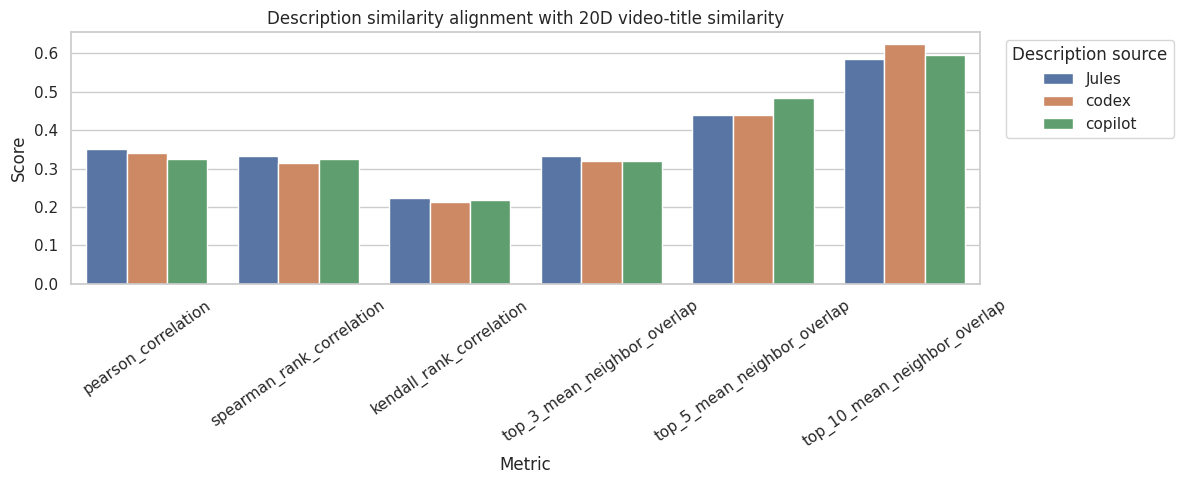

Wrote plot: /content/drive/MyDrive/Graphiko/research/title_description_similarity_alignment/latest/plots/description_vs_video_title_similarity_metrics.png


In [7]:
if not comparison_summary.empty:
    metric_columns = [
        'pearson_correlation',
        'spearman_rank_correlation',
        'kendall_rank_correlation',
        *[f'top_{k}_mean_neighbor_overlap' for k in TOP_K_VALUES],
    ]
    plot_df = comparison_summary.melt(
        id_vars='source',
        value_vars=[col for col in metric_columns if col in comparison_summary.columns],
        var_name='metric',
        value_name='value',
    )

    plt.figure(figsize=(12, 5))
    ax = sns.barplot(data=plot_df, x='metric', y='value', hue='source')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Description similarity alignment with 20D video-title similarity')
    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Description source', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

    plot_path = PLOTS_DIR / 'description_vs_video_title_similarity_metrics.png'
    plt.savefig(plot_path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'Wrote plot: {plot_path}')
else:
    print('No comparison rows to plot.')

## 8) Optional scatter diagnostics

Each point is one unordered channel pair. These plots can reveal whether a source agrees with the video-title reference globally or only in the nearest-neighbor tail.

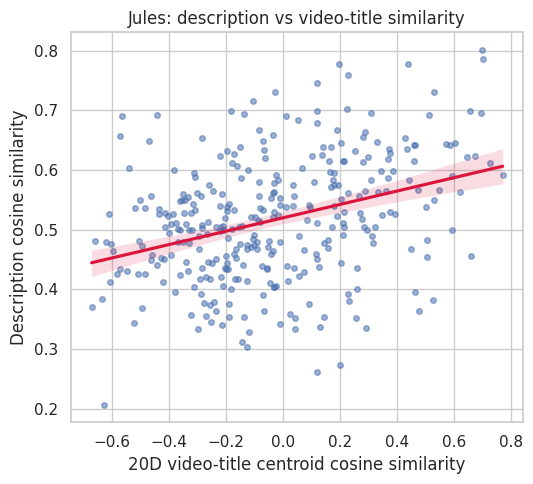

Wrote plot: /content/drive/MyDrive/Graphiko/research/title_description_similarity_alignment/latest/plots/Jules_description_vs_video_title_similarity_scatter.png


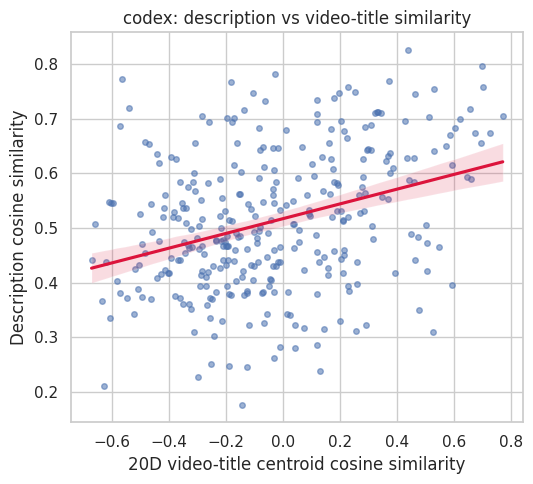

Wrote plot: /content/drive/MyDrive/Graphiko/research/title_description_similarity_alignment/latest/plots/codex_description_vs_video_title_similarity_scatter.png


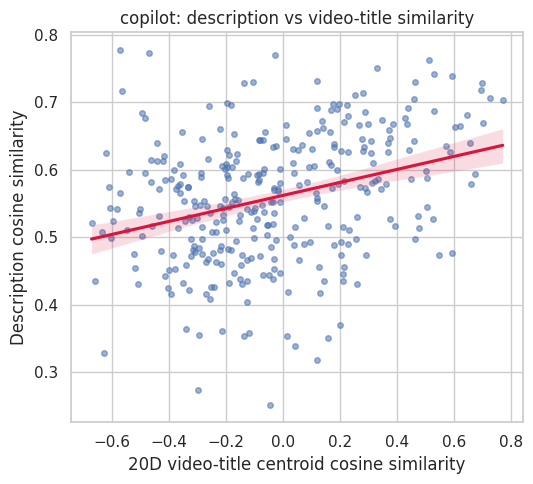

Wrote plot: /content/drive/MyDrive/Graphiko/research/title_description_similarity_alignment/latest/plots/copilot_description_vs_video_title_similarity_scatter.png


In [8]:
for source, description_matrix in description_matrices.items():
    desc_aligned, title_aligned = align_matrices(description_matrix, title_similarity)
    scatter_df = pd.DataFrame({
        'title_similarity': upper_triangle_values(title_aligned),
        'description_similarity': upper_triangle_values(desc_aligned),
    })

    plt.figure(figsize=(5.5, 5))
    ax = sns.regplot(
        data=scatter_df,
        x='title_similarity',
        y='description_similarity',
        scatter_kws={'s': 16, 'alpha': 0.55},
        line_kws={'color': 'crimson'},
    )
    ax.set_title(f'{source}: description vs video-title similarity')
    ax.set_xlabel('20D video-title centroid cosine similarity')
    ax.set_ylabel('Description cosine similarity')
    plt.tight_layout()

    safe_source = re.sub(r'[^A-Za-z0-9_.-]+', '_', source).strip('_') or 'source'
    plot_path = PLOTS_DIR / f'{safe_source}_description_vs_video_title_similarity_scatter.png'
    plt.savefig(plot_path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'Wrote plot: {plot_path}')